# Production workflow: Data Quality, Profiling, and Anomaly Detection

This notebook implements a 3-layer framework:
1. Data Quality Checks
2. Statistical Profiling
3. Anomaly Detection

In [50]:
%pip install pandas numpy matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

In [52]:
CORRUPTED_PATH = Path('../data/generated/corrupted_dataset.csv')
CLEANED_OUTPUT_PATH = Path('../data/generated/cleaned_dataset1.csv')

if not CORRUPTED_PATH.exists():
    raise FileNotFoundError(f'Input dataset not found: {CORRUPTED_PATH}')

telemetry_df = pd.read_csv(CORRUPTED_PATH)
source_name = str(CORRUPTED_PATH)

print('Loaded:', source_name)
print('Shape:', telemetry_df.shape)
telemetry_df.head()

Loaded: ..\data\generated\corrupted_dataset.csv
Shape: (824, 20)


,run_id,event_ts,device_id,device_name,storage_tier,soc_model,read_iops,write_iops,read_throughput_mb_s,write_throughput_mb_s,latency_read_p99_ms,latency_write_p99_ms,utilization_pct,nvme_queue_depth,cpu_usage_pct,memory_usage_pct,io_wait_pct,host_writes_mb,nand_writes_mb,thermal_throttling_events
0,NaN,2026-04-12T23:39:07.128512+00:00,Apple Watch_3641,Apple Watch Ultra,256GB,M1,882.7777979228597,603.434769,154.43902662564676,146.068518,24.575354,NaN,73.65061099537837,4.512088,60.370368,NaN,NaN,147.745291,124.9314445839541,4.0
1,90ee8182-6290-414f-a64d-b5ecd1cccc1d,NaN,Apple Watch_8801,Apple Watch Series 8,256GB,A16,260.421624411875,NaN,144.0215949102332,93.699400,20.731335,27.810038,43.821181178506436,NaN,200.000000,79.228818,13.482500,94.293071,222.59266916678652,3.0
2,90ee8182-6290-414f-a64d-b5ecd1cccc1d,2026-04-13T03:24:07.128512+00:00,Apple Watch_2572,Apple Watch Ultra,512GB,A15,NaN,388.124940,111.41660454400383,103.625857,19.669891,23.403790,34.5396133506337,NaN,66.503215,57.638962,12.308917,199.459304,184.6369887716716,3.0
3,3ad64548-775c-4c75-b65d-40782cb31c62,2026-04-15T04:34:07.128512+00:00,iPhone_8570,iPhone 15,256GB,M2,693.0377323562884,NaN,78.54152905909102,76.703063,13.754700,32.461272,55.684636702838446,14.749213,25.245708,73.054498,4.360235,295.329933,491.31355786724356,3.0
4,6325162b-13c7-4dc5-ab65-a1452da49e51,2026-04-15T00:39:07.128512+00:00,Apple Watch_5442,Apple Watch Series 8,256GB,A15,683.6701311935536,NaN,128.60985579262857,136.996251,22.859537,38.690412,77.90424346207153,6.250107,97.142547,59.022448,6.014478,123.440545,134.70572367502032,4.0


## Layer 1 - Data Quality Checks

In [53]:
EXPECTED_COLS = [
    'run_id', 'event_ts', 'device_id', 'device_name', 'storage_tier', 'soc_model',
    'read_iops', 'write_iops', 'read_throughput_mb_s', 'write_throughput_mb_s',
    'latency_read_p99_ms', 'latency_write_p99_ms', 'utilization_pct', 'nvme_queue_depth',
    'cpu_usage_pct', 'memory_usage_pct', 'io_wait_pct', 'host_writes_mb',
    'nand_writes_mb', 'thermal_throttling_events'
]

NUMERIC_COLS = [
    'read_iops', 'write_iops', 'read_throughput_mb_s', 'write_throughput_mb_s',
    'latency_read_p99_ms', 'latency_write_p99_ms', 'utilization_pct', 'nvme_queue_depth',
    'cpu_usage_pct', 'memory_usage_pct', 'io_wait_pct', 'host_writes_mb',
    'nand_writes_mb', 'thermal_throttling_events'
]

VALID_STORAGE = {'128GB', '256GB', '512GB', '1TB'}
VALID_SOC = {'A15', 'A16', 'A17', 'M1', 'M2'}

RANGE_RULES = {
    'cpu_usage_pct': (0, 100),
    'memory_usage_pct': (0, 100),
    'utilization_pct': (0, 100),
    'io_wait_pct': (0, 100),
    'latency_read_p99_ms': (0, None),
    'latency_write_p99_ms': (0, None),
    'read_iops': (0, None),
    'write_iops': (0, None),
    'nvme_queue_depth': (0, None),
}

In [54]:
# 1.1 Schema validation
missing_cols = sorted(set(EXPECTED_COLS) - set(telemetry_df.columns))
extra_cols = sorted(set(telemetry_df.columns) - set(EXPECTED_COLS))

coercion_report = {}
for c in NUMERIC_COLS:
    if c not in telemetry_df.columns:
        continue
    converted = pd.to_numeric(telemetry_df[c], errors='coerce')
    coercion_report[c] = {
        'null_before': int(telemetry_df[c].isna().sum()),
        'null_after': int(converted.isna().sum()),
        'bad_token_count': int(converted.isna().sum() - telemetry_df[c].isna().sum())
    }

print('Missing expected columns:', missing_cols)
print('Extra columns:', extra_cols)
pd.DataFrame(coercion_report).T.sort_values('bad_token_count', ascending=False)

Missing expected columns: []
Extra columns: []


,null_before,null_after,bad_token_count
utilization_pct,49,74,25
read_iops,47,71,24
nand_writes_mb,48,72,24
read_throughput_mb_s,50,74,24
write_iops,73,73,0
write_throughput_mb_s,73,73,0
latency_write_p99_ms,72,72,0
latency_read_p99_ms,77,77,0
cpu_usage_pct,72,72,0
nvme_queue_depth,70,70,0


Critical key device_id null %: 5.95
Average row null %: 8.23


,null_pct
latency_read_p99_ms,9.34
thermal_throttling_events,9.22
host_writes_mb,9.22
read_throughput_mb_s,8.98
memory_usage_pct,8.98
utilization_pct,8.98
write_iops,8.86
device_name,8.86
write_throughput_mb_s,8.86
nand_writes_mb,8.74


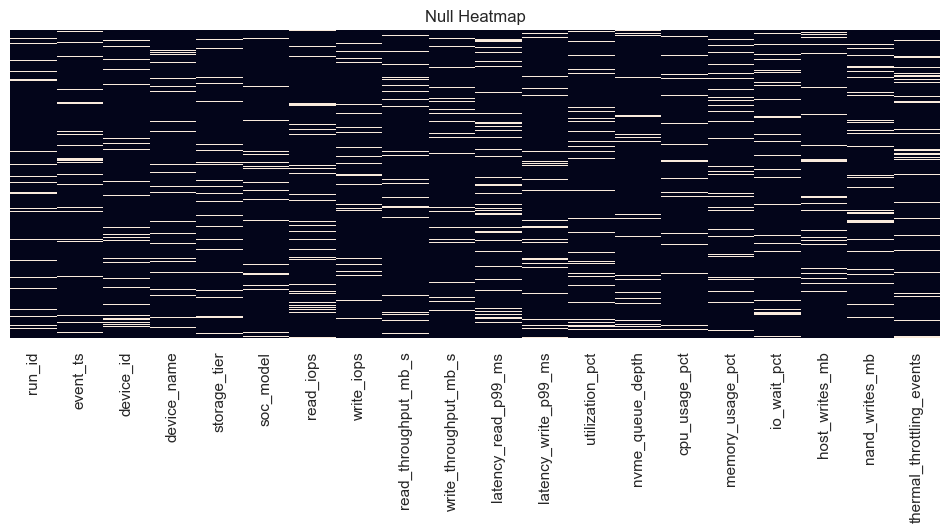

In [55]:
workload_profile = telemetry_df.copy()
for c in NUMERIC_COLS:
    if c in workload_profile.columns:
        workload_profile[c] = pd.to_numeric(workload_profile[c], errors='coerce')
workload_profile['event_ts'] = pd.to_datetime(workload_profile['event_ts'], errors='coerce', utc=True)

# 1.2 Missing data checks
col_null_pct = (workload_profile.isna().mean() * 100).sort_values(ascending=False).round(2)
row_null_pct = workload_profile.isna().mean(axis=1) * 100

print('Critical key device_id null %:', round(workload_profile['device_id'].isna().mean() * 100, 2))
print('Average row null %:', round(row_null_pct.mean(), 2))
display(col_null_pct.to_frame('null_pct'))

plt.figure(figsize=(12, 4))
sns.heatmap(workload_profile.isna(), cbar=False, yticklabels=False)
plt.title('Null Heatmap')
plt.show()

In [56]:
# 1.3 Duplicate checks
exact_dups = int(workload_profile.duplicated().sum())
pk_dups = int(workload_profile.duplicated(subset=['device_id', 'event_ts']).sum())

near_dups = 0
ts_ok = workload_profile.dropna(subset=['device_id', 'event_ts']).sort_values(['device_id', 'event_ts']).copy()
if not ts_ok.empty:
    delta = ts_ok.groupby('device_id')['event_ts'].diff().abs().dt.total_seconds()
    near_dups = int(((delta > 0) & (delta <= 5)).sum())

print('Exact duplicates:', exact_dups)
print('Primary key duplicates (device_id,event_ts):', pk_dups)
print('Near duplicates (same device within 5s):', near_dups)

Exact duplicates: 24
Primary key duplicates (device_id,event_ts): 28
Near duplicates (same device within 5s): 0


In [57]:
# 1.4 Range checks + 1.5 categorical checks + 1.6 timestamp checks
range_issues = []
for col, (lo, hi) in RANGE_RULES.items():
    if col not in workload_profile.columns:
        continue
    bad = pd.Series(False, index=workload_profile.index)
    if lo is not None:
        bad = bad | (workload_profile[col] < lo)
    if hi is not None:
        bad = bad | (workload_profile[col] > hi)
    range_issues.append({'column': col, 'violations': int(bad.fillna(False).sum())})

cat_issues = {
    'soc_model_invalid': int((~workload_profile['soc_model'].isin(VALID_SOC)).fillna(True).sum()),
    'storage_tier_invalid': int((~workload_profile['storage_tier'].isin(VALID_STORAGE)).fillna(True).sum()),
}

ts_parsed_pct = round(workload_profile['event_ts'].notna().mean() * 100, 2)
now_utc = pd.Timestamp.utcnow().tz_localize('UTC') if pd.Timestamp.utcnow().tzinfo is None else pd.Timestamp.utcnow()
future_ts = int((workload_profile['event_ts'] > now_utc).fillna(False).sum())
old_ts = int((workload_profile['event_ts'] < pd.Timestamp('2000-01-01', tz='UTC')).fillna(False).sum())

display(pd.DataFrame(range_issues).sort_values('violations', ascending=False))
print('Categorical issues:', cat_issues)
print('Timestamp parse success %:', ts_parsed_pct)
print('Future timestamps:', future_ts)
print('Very old timestamps:', old_ts)

C:\Users\rakes\AppData\Local\Temp\ipykernel_9816\952319183.py:19: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  now_utc = pd.Timestamp.utcnow().tz_localize('UTC') if pd.Timestamp.utcnow().tzinfo is None else pd.Timestamp.utcnow()


,column,violations
0,cpu_usage_pct,16
2,utilization_pct,16
3,io_wait_pct,16
4,latency_read_p99_ms,16
1,memory_usage_pct,0
5,latency_write_p99_ms,0
6,read_iops,0
7,write_iops,0
8,nvme_queue_depth,0


Categorical issues: {'soc_model_invalid': 75, 'storage_tier_invalid': 73}
Timestamp parse success %: 92.23
Future timestamps: 0
Very old timestamps: 0


In [58]:
# 4.1 Data Quality Score
completeness = (1 - workload_profile.isna().mean().mean()) * 100
validity = 100 - (pd.DataFrame(range_issues)['violations'].sum() / max(len(workload_profile) * max(len(range_issues), 1), 1) * 100)
uniqueness = (1 - (exact_dups / max(len(workload_profile), 1))) * 100
consistency = 100 - ((cat_issues['soc_model_invalid'] + cat_issues['storage_tier_invalid']) / max(2 * len(workload_profile), 1) * 100)
dq_score = (completeness + validity + uniqueness + consistency) / 4

dq = pd.DataFrame([
    {'component': 'completeness', 'score': round(completeness, 2)},
    {'component': 'validity', 'score': round(validity, 2)},
    {'component': 'uniqueness', 'score': round(uniqueness, 2)},
    {'component': 'consistency', 'score': round(consistency, 2)},
    {'component': 'overall_dq_score', 'score': round(dq_score, 2)},
])
dq

,component,score
0,completeness,91.77
1,validity,99.14
2,uniqueness,97.09
3,consistency,91.02
4,overall_dq_score,94.75


## Layer 2 - Statistical Profiling

In [59]:
import sys
import importlib
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import src.features.feature_engineering as feature_engineering
importlib.reload(feature_engineering)
build_features = feature_engineering.build_features

# Apply all feature engineering — replaces the inline feature block
workload_profile = build_features(workload_profile)

# Persist the enriched + cleaned dataset
workload_profile.to_csv(CLEANED_OUTPUT_PATH, index=False)
print('Saved enriched dataset to:', CLEANED_OUTPUT_PATH)
print('New feature columns:', [
    'write_amplification', 'throughput_per_iop', 'saturation_score',
    'total_iops', 'io_mix', 'cpu_to_io_ratio', 'io_wait_to_latency_ratio',
    'rolling_mean_latency', 'rolling_std_latency',
    'rolling_mean_iops', 'rolling_std_iops', 'burstiness',
])

profile_cols = [
    'read_iops', 'write_iops', 'latency_read_p99_ms', 'latency_write_p99_ms',
    'cpu_usage_pct', 'io_wait_pct', 'total_iops', 'io_mix',
    'write_amplification', 'throughput_per_iop', 'saturation_score',
    'cpu_to_io_ratio', 'io_wait_to_latency_ratio', 'burstiness',
]

distribution_summary = workload_profile[profile_cols].describe(percentiles=[0.5, 0.95, 0.99]).T
distribution_summary[['mean', '50%', 'std', 'min', '95%', '99%', 'max']]

Saved enriched dataset to: ..\data\generated\cleaned_dataset1.csv
New feature columns: ['write_amplification', 'throughput_per_iop', 'saturation_score', 'total_iops', 'io_mix', 'cpu_to_io_ratio', 'io_wait_to_latency_ratio', 'rolling_mean_latency', 'rolling_std_latency', 'rolling_mean_iops', 'rolling_std_iops', 'burstiness']


,mean,50%,std,min,95%,99%,max
read_iops,226532.847312,792.279181,1.486356e+06,10.000000,1180.841092,9.999999e+06,9.999999e+06
write_iops,606.212932,605.430396,1.492484e+02,139.045459,856.882137,9.598719e+02,1.085024e+03
latency_read_p99_ms,19.568136,20.051046,6.542196e+00,-10.000000,28.007840,3.118155e+01,3.563086e+01
latency_write_p99_ms,30.325158,30.065559,6.054070e+00,12.830890,40.497341,4.446707e+01,4.976312e+01
cpu_usage_pct,63.125077,61.501208,2.809956e+01,5.000000,97.035175,2.000000e+02,2.000000e+02
io_wait_pct,9.733473,9.886502,5.537773e+00,-5.000000,18.557893,2.256510e+01,3.075621e+01
total_iops,235638.674370,1405.139759,1.513505e+06,408.176714,1883.430712,1.000051e+07,1.000100e+07
io_mix,0.571898,0.566978,1.111289e-01,0.014063,0.728139,9.999525e-01,9.999648e-01
write_amplification,3.275058,1.510953,1.518339e+01,0.005669,3.323691,9.164748e+01,1.921702e+02
throughput_per_iop,0.153184,0.146902,5.517813e-02,0.000015,0.247702,3.064627e-01,6.833538e-01


In [60]:
# 2.2 Skew detection
skew_df = pd.DataFrame({
    'mean': workload_profile[profile_cols].mean(),
    'median': workload_profile[profile_cols].median(),
})
skew_df['mean_minus_median'] = skew_df['mean'] - skew_df['median']
skew_df['mean_to_median_ratio'] = skew_df['mean'] / skew_df['median'].replace(0, np.nan)
skew_df.sort_values('mean_minus_median', ascending=False)

,mean,median,mean_minus_median,mean_to_median_ratio
total_iops,235638.674370,1405.139759,234233.534610,167.697678
read_iops,226532.847312,792.279181,225740.568132,285.925533
saturation_score,341.647261,312.504498,29.142763,1.093256
cpu_to_io_ratio,9.399321,5.910590,3.488732,1.590251
write_amplification,3.275058,1.510953,1.764105,2.167545
burstiness,1.878367,0.215736,1.662631,8.706770
cpu_usage_pct,63.125077,61.501208,1.623869,1.026404
write_iops,606.212932,605.430396,0.782536,1.001293
latency_write_p99_ms,30.325158,30.065559,0.259599,1.008634
io_wait_to_latency_ratio,0.337065,0.326004,0.011062,1.033931


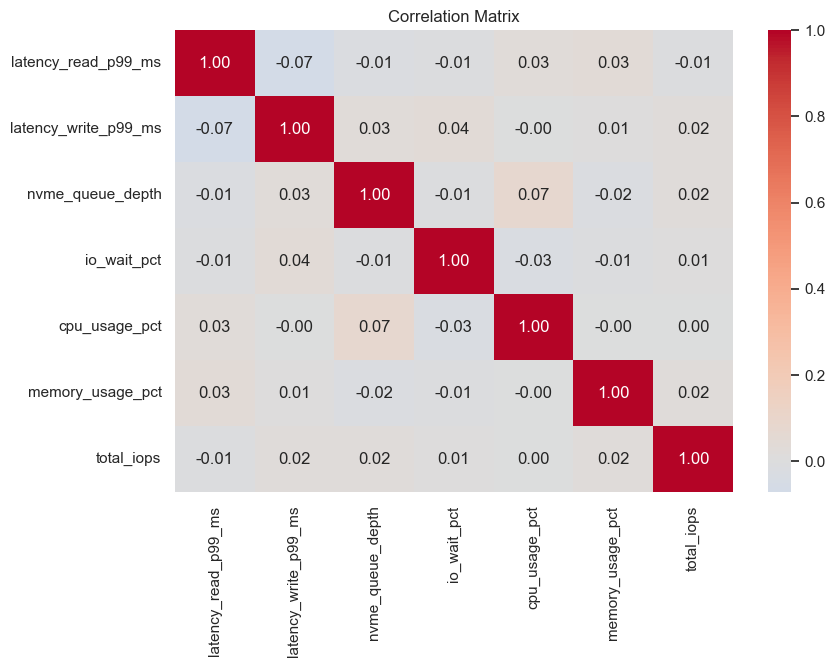

,latency_read_p99_ms,latency_write_p99_ms,nvme_queue_depth,io_wait_pct,cpu_usage_pct,memory_usage_pct,total_iops
latency_read_p99_ms,1.000000,-0.072150,-0.014229,-0.005587,0.029972,0.033308,-0.009262
latency_write_p99_ms,-0.072150,1.000000,0.030083,0.037037,-0.001361,0.006270,0.019939
nvme_queue_depth,-0.014229,0.030083,1.000000,-0.013315,0.072757,-0.020051,0.020195
io_wait_pct,-0.005587,0.037037,-0.013315,1.000000,-0.028783,-0.012550,0.008165
cpu_usage_pct,0.029972,-0.001361,0.072757,-0.028783,1.000000,-0.001684,0.000982
memory_usage_pct,0.033308,0.006270,-0.020051,-0.012550,-0.001684,1.000000,0.022138
total_iops,-0.009262,0.019939,0.020195,0.008165,0.000982,0.022138,1.000000


In [61]:
# 2.3 Correlation matrix
corr_cols = ['latency_read_p99_ms', 'latency_write_p99_ms', 'nvme_queue_depth', 'io_wait_pct', 'cpu_usage_pct', 'memory_usage_pct', 'total_iops']
corr = workload_profile[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

corr

In [62]:
# 2.4 Grouped profiling
group_profile = workload_profile.groupby(['device_name', 'soc_model', 'storage_tier'], dropna=False)[['total_iops', 'latency_read_p99_ms', 'latency_write_p99_ms', 'write_amplification']].agg(['mean', 'median', 'count'])
group_profile.sort_values(('total_iops', 'mean'), ascending=False).head(20)

total_iops                      \
                                                     mean        median count   
device_name          soc_model storage_tier                                     
iPad Air M1          A15       512GB         1.000072e+07  1.000072e+07     1   
iPhone 15 Pro        M1        512GB         1.000044e+07  1.000044e+07     1   
MacBook Air M2       NaN       1TB           1.000042e+07  1.000042e+07     1   
Apple Watch Ultra    M2        256GB         5.000998e+06  5.000998e+06     2   
MacBook Air M2       M2        128GB         5.000948e+06  5.001085e+06     4   
Apple Watch Series 8 A15       512GB         3.334530e+06  1.591461e+03     3   
                     A17       1TB           3.334523e+06  1.479193e+03     3   
NaN                  A17       256GB         3.334481e+06  1.623548e+03     3   
iPhone 14 Pro        A17       256GB         3.334479e+06  1.668234e+03     3   
NaN                  A17       1TB           3.334461e+06  1.405559e+03     3   
iPad Pro M2          A17       128GB         2.501274e+06  1.663489e+03     4   
                               256GB         2.501040e+06  1.425741e+03     4   
                     A15       512GB         2.500939e+06  1.135874e+03     4   
                     M1        1TB           2.001175e+06  1.365462e+03     5   
iPad Air M1          A16       128GB         1.429834e+06  1.470278e+03     7   
NaN                  M1        1TB           2.052625e+03  2.026954e+03     4   
Apple Watch Series 8 A16       64TB          1.987972e+03  1.987972e+03     1   
                     M1        512GB         1.905151e+03  1.905151e+03     2   
Apple Watch Ultra    M9        256GB         1.901144e+03  1.901144e+03     1   
Mac Mini M2          A15       64TB          1.900858e+03  1.900858e+03     1   

                                            latency_read_p99_ms             \
                                                           mean     median   
device_name          soc_model storage_tier                                  
iPad Air M1          A15       512GB                  20.538810  20.538810   
iPhone 15 Pro        M1        512GB                  13.916408  13.916408   
MacBook Air M2       NaN       1TB                    19.483558  19.483558   
Apple Watch Ultra    M2        256GB                  19.907451  21.436484   
MacBook Air M2       M2        128GB                  13.837379  19.992140   
Apple Watch Series 8 A15       512GB                  18.730428  20.016044   
                     A17       1TB                    22.672432  21.956121   
NaN                  A17       256GB                  19.052783  19.052783   
iPhone 14 Pro        A17       256GB                  23.559821  25.545849   
NaN                  A17       1TB                    16.995585  20.749711   
iPad Pro M2          A17       128GB                  18.914593  20.016429   
                               256GB                  19.261627  21.504896   
                     A15       512GB                  16.151915  16.205629   
                     M1        1TB                    20.407274  18.843659   
iPad Air M1          A16       128GB                  19.341918  18.702434   
NaN                  M1        1TB                    20.865649  21.130598   
Apple Watch Series 8 A16       64TB                   22.255263  22.255263   
                     M1        512GB                  20.387791  20.387791   
Apple Watch Ultra    M9        256GB                  21.994813  21.994813   
Mac Mini M2          A15       64TB                   19.789570  19.789570   

                                                  latency_write_p99_ms  \
                                            count                 mean   
device_name          soc_model storage_tier                              
iPad Air M1          A15       512GB            1            26.422737   
iPhone 15 Pro        M1        512GB            1                  NaN   
MacBook Air M2    

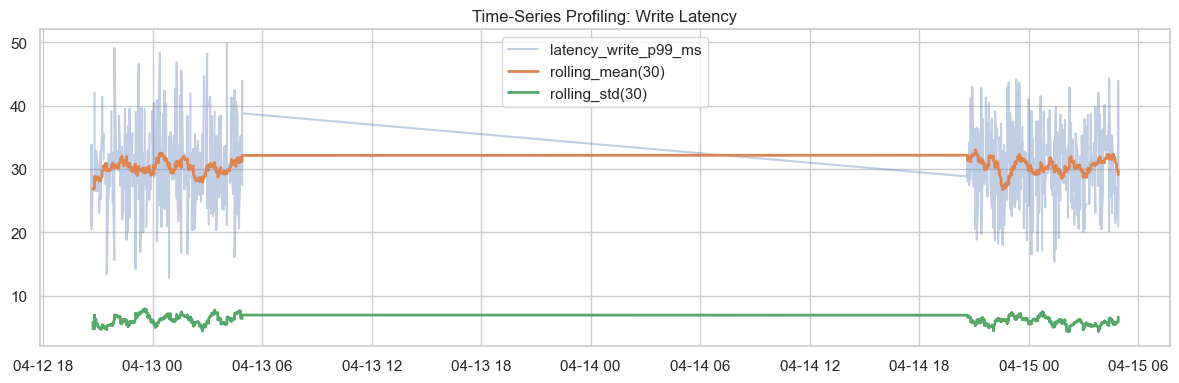

In [63]:
# 2.5 Time-series profiling
ts = workload_profile.dropna(subset=['event_ts']).sort_values('event_ts').copy()
ts = ts.set_index('event_ts')

roll_mean = ts['latency_write_p99_ms'].rolling(30, min_periods=5).mean()
roll_std = ts['latency_write_p99_ms'].rolling(30, min_periods=5).std()

plt.figure(figsize=(12, 4))
plt.plot(ts.index, ts['latency_write_p99_ms'], alpha=0.35, label='latency_write_p99_ms')
plt.plot(roll_mean.index, roll_mean, label='rolling_mean(30)', linewidth=2)
plt.plot(roll_std.index, roll_std, label='rolling_std(30)', linewidth=2)
plt.title('Time-Series Profiling: Write Latency')
plt.legend()
plt.tight_layout()
plt.show()

## Layer 3 - Anomaly Detection

In [64]:
anom = workload_profile.copy()

# 3.1 Rule-based
anom['rule_high_write_latency'] = anom['latency_write_p99_ms'] > 100
anom['rule_high_cpu'] = anom['cpu_usage_pct'] > 95
anom['rule_io_contention'] = anom['io_wait_pct'] > 30

# 3.2 Z-score baseline
z_cols = ['latency_write_p99_ms', 'latency_read_p99_ms', 'cpu_usage_pct', 'io_wait_pct', 'total_iops']
for c in z_cols:
    mu = anom[c].mean()
    sd = anom[c].std()
    anom[f'z_{c}'] = (anom[c] - mu) / (sd if pd.notna(sd) and sd != 0 else np.nan)

anom['zscore_anomaly'] = anom[[f'z_{c}' for c in z_cols]].abs().max(axis=1) > 3

# 3.3 Multivariate rules
anom['disk_issue'] = (anom['latency_write_p99_ms'] > 80) & (anom['io_wait_pct'] > 20)
anom['compute_issue'] = (anom['latency_write_p99_ms'] > 80) & (anom['cpu_usage_pct'] > 85)
anom['suspicious_low_signal_high_latency'] = (anom['latency_write_p99_ms'] > 80) & (anom['cpu_usage_pct'] < 40) & (anom['io_wait_pct'] < 10)

anom['is_anomaly'] = anom[[
    'rule_high_write_latency', 'rule_high_cpu', 'rule_io_contention',
    'zscore_anomaly', 'disk_issue', 'compute_issue', 'suspicious_low_signal_high_latency'
]].any(axis=1)

anom['root_cause'] = np.select(
    [anom['disk_issue'], anom['compute_issue'], anom['suspicious_low_signal_high_latency']],
    ['disk', 'compute', 'suspicious'],
    default='other_or_normal'
)

column_statistics = {
    'total_rows': len(anom),
    'anomaly_rows': int(anom['is_anomaly'].sum()),
    'anomaly_rate_pct': round(anom['is_anomaly'].mean() * 100, 2),
}
print(column_statistics)
anom['root_cause'].value_counts()

{'total_rows': 824, 'anomaly_rows': 85, 'anomaly_rate_pct': np.float64(10.32)}


root_cause
other_or_normal    824
Name: count, dtype: int64

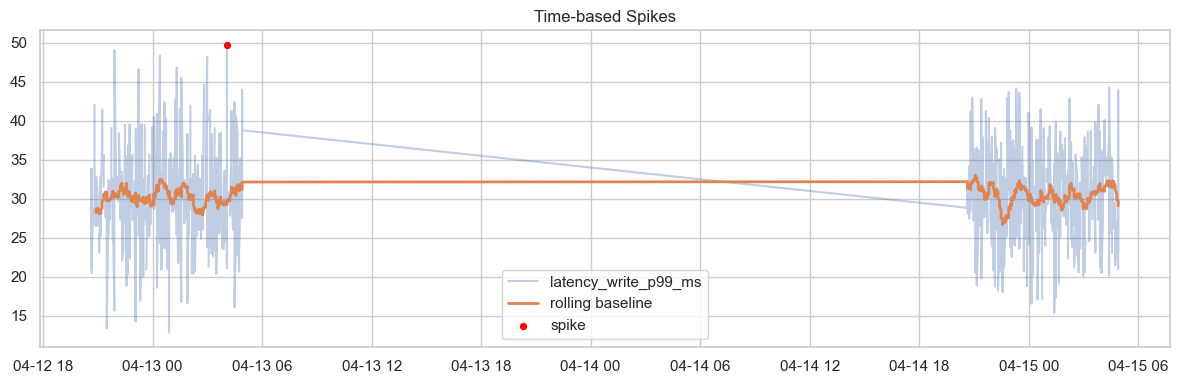

Time-based spikes: 1


In [65]:
# 3.4 Time-based anomaly spikes
if anom['event_ts'].notna().any():
    t = anom.dropna(subset=['event_ts']).sort_values('event_ts').set_index('event_ts')
    latency = t['latency_write_p99_ms']
    baseline = latency.rolling(30, min_periods=10).mean()
    spread = latency.rolling(30, min_periods=10).std()
    t['time_spike'] = latency > (baseline + 3 * spread)

    plt.figure(figsize=(12, 4))
    plt.plot(t.index, latency, alpha=0.35, label='latency_write_p99_ms')
    plt.plot(t.index, baseline, label='rolling baseline', linewidth=2)
    plt.scatter(t.index[t['time_spike']], latency[t['time_spike']], color='red', s=18, label='spike')
    plt.title('Time-based Spikes')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('Time-based spikes:', int(t['time_spike'].sum()))
else:
    print('No parseable timestamps available for time-based anomalies.')

In [66]:
out_path = Path('../data/generated/anomaly_detection_output.csv')
anom.to_csv(out_path, index=False)
print('Saved anomaly output to:', out_path)

Saved anomaly output to: ..\data\generated\anomaly_detection_output.csv
